# Exploring Victorian electricity demand

Goal: inspect one month of AEMO demand data, check its quality,
and identify daily and weekly patterns.

Source: AEMO aggregated price and demand data, Victoria (VIC1). We used the August 2026 data.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Works when the notebook starts in the project or notebooks folder.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

files = sorted((ROOT / "data" / "raw").glob("*.csv"))
assert len(files) == 1, "Place exactly one monthly CSV in data/raw for now."

df = pd.read_csv(files[0])

print(f"File: {files[0].name}")
print(f"Rows: {len(df):,}")
df.head()

File: PRICE_AND_DEMAND_202608_VIC1.csv
Rows: 8,928


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2026/08/01 00:05:00,6486.74,92.76,TRADE
1,VIC1,2026/08/01 00:10:00,6480.36,99.19,TRADE
2,VIC1,2026/08/01 00:15:00,6548.49,122.37,TRADE
3,VIC1,2026/08/01 00:20:00,6490.39,99.19,TRADE
4,VIC1,2026/08/01 00:25:00,6486.28,91.50,TRADE


Inspect the data:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   REGION          8928 non-null   str    
 1   SETTLEMENTDATE  8928 non-null   str    
 2   TOTALDEMAND     8928 non-null   float64
 3   RRP             8928 non-null   float64
 4   PERIODTYPE      8928 non-null   str    
dtypes: float64(2), str(3)
memory usage: 348.9 KB


Check missing values and duplicate rows

In [5]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
REGION            0
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
PERIODTYPE        0
dtype: int64

Duplicate rows: 0


Everything seems to be clean. Let's create a chart.

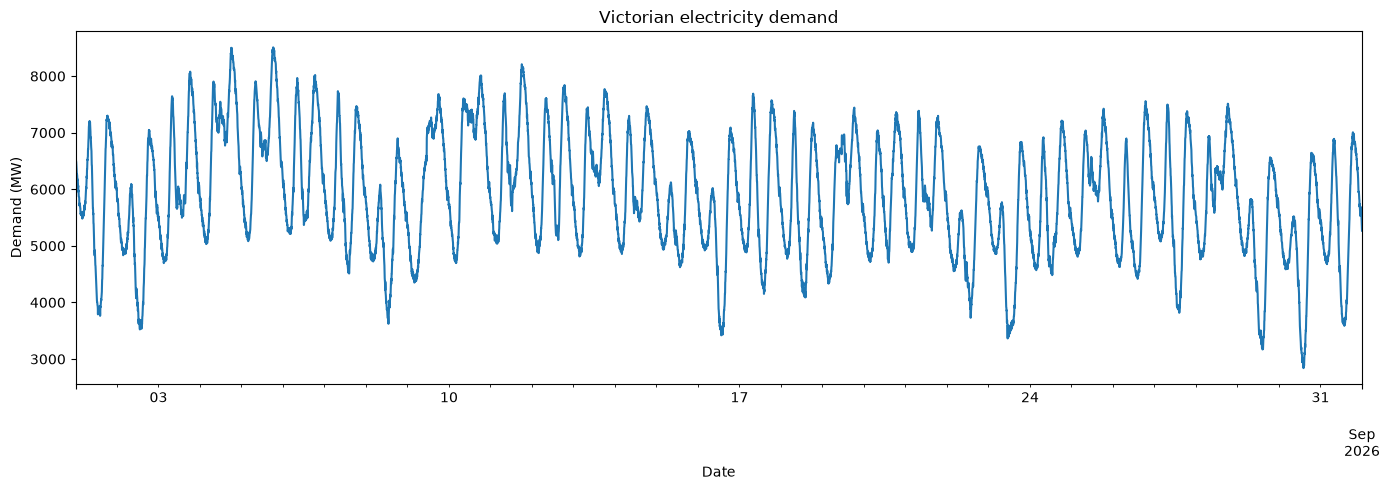

In [6]:
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
df = df.sort_values("SETTLEMENTDATE")

ax = df.plot(
    x="SETTLEMENTDATE",
    y="TOTALDEMAND",
    figsize=(14, 5),
    legend=False,
    title="Victorian electricity demand",
)

ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
plt.tight_layout()
plt.show()